# Run SOM with different configurations

- 1. Independent HFR 
    - a) Solo Coffs Harbour
    - b) Solo Newcastle 

- 2. Solo HFR + Temperature

- 3. Both HFR together

## Data & Packages

In [41]:
import warnings
get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')

In [2]:
#------------------------------------------------------
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from xpysom import XPySom
from datetime import datetime
import glob
#------------------------------------------------------

git = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/'

path_data = git+'Data/'
coffs = xr.open_dataset(path_data+'HFR/Vectors_Filled/currents_dineof_COFFS_Y2019M07_Y2020M12.nc')
newc = xr.open_dataset(path_data+'HFR/Vectors_Filled/currents_dineof_NEWC_Y2019M07_Y2021M12.nc')

path_save_soms = git+'Analysis/Self_Organizing_Maps/SOM_Different_Tests/saved_soms/'

In [3]:
newcastle_u = newc['u'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]
newcastle_v = newc['v'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]

coffs_u = coffs['u'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]
coffs_v = coffs['v'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]

/tmp/ipykernel_11380/2466492676.py:1: RuntimeWarning: Mean of empty slice
  newcastle_u = newc['u'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]
/tmp/ipykernel_11380/2466492676.py:2: RuntimeWarning: Mean of empty slice
  newcastle_v = newc['v'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]
/tmp/ipykernel_11380/2466492676.py:4: RuntimeWarning: Mean of empty slice
  coffs_u = coffs['u'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]
/tmp/ipykernel_11380/2466492676.py:5: RuntimeWarning: Mean of empty slice
  coffs_v = coffs['v'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]


## Functions

In [24]:
def run_som_only_radar(u,v,rows,cols,name):

    # choose the analysis you want
    som_space = True
    som_time = False

    #%% Reshape and normalize the dataset 
    [s_t, s_x, s_y] = u.shape
    u_r = np.reshape(u, (s_t, s_x*s_y))
    v_r = np.reshape(v, (s_t, s_x*s_y))

    variables_normed = [u_r, v_r]
    variables = [u_r, v_r]
    store_mean = np.zeros(len(variables))
    store_std = np.zeros(len(variables))

    #%% Reshape and normalize the dataset 

    [s_t, s_x, s_y] = u.shape
    u_r = np.reshape(u, (s_t, s_x*s_y))
    v_r = np.reshape(v, (s_t, s_x*s_y))
    variables_normed = [u_r, v_r]
    variables = [u_r, v_r]
    store_mean = np.zeros(len(variables))
    store_std = np.zeros(len(variables))

    for i in range(0,len(variables_normed)):
        variables_normed[i] =  (variables[i] - np.nanmean(variables[i])) / np.nanstd(variables[i])
        store_mean[i] = np.nanmean(variables[i])
        store_std[i] = np.nanstd(variables[i])

    # Normalizing
    if som_space:
        data_nan = np.concatenate(variables_normed[:],
                                  axis=1)
        print('You have chosen SOM spatial analysis')
        print('Your data shape is '+str(data_nan.shape))

    #Here the dataset is completely full 
    mask_nan = np.isnan(data_nan[0,:])
    data = data_nan[:,~mask_nan]


    #%% Run SOM 
    data[np.isnan(data)]=0

    """
    For spatial SOM: time(rows) * variables(columns), 
    variables are the concatenation of U and V values for each pixel 

    For temporal SOM: pixels(rows) * variables(columns), 
    variables are the concatenation of U and V values for each timestep 

    """

    number_neurons = rows * cols;

    n_init = 200 # number of iterations in the training
    sigma = 1.5 # radius of the neighborhood function
    learning_rate = 1

    if som_time:
        data_run = data.T.copy()
    elif som_space:
        data_run = data.copy()

    start_time = datetime.now()

    som = XPySom(cols, rows, data_run.shape[1],
                sigma = sigma, learning_rate = learning_rate,
                topology = 'hexagonal', xp = np)

    print('initializing')
    som.pca_weights_init(data_run) # using the pca initialization

    print('training')
    som.train_batch(data_run, n_init, verbose = True)

    end_time = datetime.now()
    print('Duration: {}'.format(end_time - start_time))


    #%% Retrieve SOM outputs

    def return_winner(point, matrix_result):
        """
        This function is to retrieve the number of the winning neuron for each point
        """

        win = som.winner(point) # this is to retrieve the BMU of each point
        r = win[0]
        c = win[1]
        neu = matrix_result[r,c]

        return neu

    neurs = np.arange(0,cols*rows).reshape((cols,rows))

    final_weights_normed = som.get_weights().copy() # this is to retrieve the final neurons
    winners = np.array([return_winner(data_run[i], neurs) for i in range(0,len(data_run))])

    if som_space:
        win_r = np.concatenate([winners,winners])
        #rs = data_nan.reshape((s_t*2,s_x,s_y))

    def denorm(neu_n, ar, ar_s):
        thing = neu_n*(np.nanmax(ar_s)-np.nanmin(ar_s))+np.nanmin(ar_s)
        neu = np.nanmean(ar)+np.nanstd(ar)*thing
        return neu

    neuron_u = np.nan*np.zeros((rows,cols,s_x,s_y))
    neuron_v = np.nan*np.zeros((rows,cols,s_x,s_y))

    for i in range(rows):
        for j in range(cols):

            neu = np.copy(data_nan[0,:])
            neu[~mask_nan] = final_weights_normed[i,j,:]
            neu_u_n = neu[0:s_x*s_y]
            neu_v_n = neu[s_x*s_y:2*s_x*s_y]

            neu_u = neu_u_n*store_std[0]+store_mean[0]
            neu_v = neu_v_n*store_std[1]+store_mean[1]

            neu_u[neu_u==0]=np.nan
            neu_v[neu_v==0]=np.nan

            neu_u_r = neu_u.reshape((s_x,s_y))
            neu_v_r = neu_v.reshape((s_x,s_y))

            neuron_u[i,j,:,:] = neu_u_r
            neuron_v[i,j,:,:] = neu_v_r
    np.savez(path_save_soms+name+'.npz',som=som,neuron_u=neuron_u,neuron_v=neuron_v,bmus=winners)
    print(name+' Done!')
        
#------------------------------------------------------

def run_som_radar_sst(u, v, sst, rows, cols, name):
    
    # choose the analysis you want
    som_space = True
    som_time = False

    #%% Reshape and normalize the dataset 
    [s_t, s_x, s_y] = u.shape
    u_r = np.reshape(u, (s_t, s_x*s_y))
    v_r = np.reshape(v, (s_t, s_x*s_y))
        
    [s_t_sst, s_x_sst, s_y_sst] = sst.shape
    sst_r = np.reshape(sst, (s_t_sst, s_x_sst*s_y_sst))
    
    
    variables_normed = [u_r, v_r, sst_r]
    variables = [u_r, v_r, sst_r]
    store_mean = np.zeros(len(variables))
    store_std = np.zeros(len(variables))



    for i in range(0,len(variables_normed)):
        variables_normed[i] =  (variables[i] - np.nanmean(variables[i])) / np.nanstd(variables[i])
        store_mean[i] = np.nanmean(variables[i])
        store_std[i] = np.nanstd(variables[i])

    # Normalizing
    if som_space:
        data_nan = np.concatenate(variables_normed[:],
                                  axis=1)
        print('You have chosen SOM spatial analysis')
        print('Your data shape is '+str(data_nan.shape))

    #Here the dataset is completely full 
    mask_nan = np.isnan(data_nan[0,:])
    data = data_nan[:,~mask_nan]


    #%% Run SOM 
    data[np.isnan(data)]=0

    """
    For spatial SOM: time(rows) * variables(columns), 
    variables are the concatenation of U and V values for each pixel 

    For temporal SOM: pixels(rows) * variables(columns), 
    variables are the concatenation of U and V values for each timestep 

    """

    number_neurons = rows * cols;

    n_init = 200 # number of iterations in the training
    sigma = 1.5 # radius of the neighborhood function
    learning_rate = 1

    if som_time:
        data_run = data.T.copy()
    elif som_space:
        data_run = data.copy()

    start_time = datetime.now()

    som = XPySom(cols, rows, data_run.shape[1],
                sigma = sigma, learning_rate = learning_rate,
                topology = 'hexagonal', xp = np)

    print('initializing')
    som.pca_weights_init(data_run) # using the pca initialization

    print('training')
    som.train_batch(data_run, n_init, verbose = True)

    end_time = datetime.now()
    print('Duration: {}'.format(end_time - start_time))


    #%% Retrieve SOM outputs

    def return_winner(point, matrix_result):
        """
        This function is to retrieve the number of the winning neuron for each point
        """

        win = som.winner(point) # this is to retrieve the BMU of each point
        r = win[0]
        c = win[1]
        neu = matrix_result[r,c]

        return neu

    neurs = np.arange(0,cols*rows).reshape((cols,rows))

    final_weights_normed = som.get_weights().copy() # this is to retrieve the final neurons
    winners = np.array([return_winner(data_run[i], neurs) for i in range(0,len(data_run))])

    if som_space:
        win_r = np.concatenate([winners,winners])
        #rs = data_nan.reshape((s_t*2,s_x,s_y))

    def denorm(neu_n, ar, ar_s):
        thing = neu_n*(np.nanmax(ar_s)-np.nanmin(ar_s))+np.nanmin(ar_s)
        neu = np.nanmean(ar)+np.nanstd(ar)*thing
        return neu

    neuron_u = np.nan*np.zeros((rows, cols, s_x, s_y))
    neuron_v = np.nan*np.zeros((rows, cols, s_x, s_y))
    neuron_sst = np.nan*np.zeros((rows, cols, s_x_sst, s_y_sst))

    for i in range(rows):
        for j in range(cols):

            neu = np.copy(data_nan[0,:])
            neu[~mask_nan] = final_weights_normed[i,j,:]
            neu_u_n = neu[0:s_x*s_y]
            neu_v_n = neu[s_x*s_y:2*s_x*s_y]
            neu_sst_n = neu[2*s_x*s_y:]

            neu_u = neu_u_n*store_std[0]+store_mean[0]
            neu_v = neu_v_n*store_std[1]+store_mean[1]
            neu_sst = neu_sst_n*store_std[2]+store_mean[2]

            neu_u[neu_u==0]=np.nan
            neu_v[neu_v==0]=np.nan
            neu_sst[neu_sst==0]=np.nan

            neu_u_r = neu_u.reshape((s_x,s_y))
            neu_v_r = neu_v.reshape((s_x,s_y))
            neu_sst_r = neu_sst.reshape((s_x_sst, s_y_sst))

            neuron_u[i,j,:,:] = neu_u_r
            neuron_v[i,j,:,:] = neu_v_r
            neuron_sst[i,j,:,:] = neu_sst_r

    np.savez(path_save_soms+name+'.npz',
             som=som,
             neuron_u=neuron_u,
             neuron_v=neuron_v,
             neuron_sst=neuron_sst,
             bmus=winners)
    
    print(name+' Done!')

#------------------------------------------------------

def run_both_radars(u1, v1, u2, v2, rows, cols, name):

    # choose the analysis you want
    som_space = True
    som_time = False


    #%% Reshape and normalize the dataset 

    [s_t_n, s_x_n, s_y_n] = u1.shape

    u_r_n = np.reshape(u1, (s_t_n, s_x_n*s_y_n))
    v_r_n = np.reshape(v1, (s_t_n, s_x_n*s_y_n))


    [s_t_c, s_x_c, s_y_c] = u2.shape
    u_r_c = np.reshape(u2, (s_t_c, s_x_c*s_y_c))
    v_r_c = np.reshape(v2, (s_t_c, s_x_c*s_y_c))

    variables_normed = [u_r_n, v_r_n, u_r_c, v_r_c]
    variables = [u_r_n, v_r_n, u_r_c, v_r_c]
    
    store_mean = np.zeros(len(variables))
    store_std = np.zeros(len(variables))


    for i in range(0,len(variables_normed)):
        variables_normed[i] =  (variables[i] - np.nanmean(variables[i])) / np.nanstd(variables[i])
        store_mean[i] = np.nanmean(variables[i])
        store_std[i] = np.nanstd(variables[i])

    # Normalizing
    if som_space:
        data_nan = np.concatenate(variables_normed[:],
                                  axis=1)
        print('You have chosen SOM spatial analysis')
        print('Your data shape is '+str(data_nan.shape))


    #Here the dataset is completely full 
    mask_nan = np.isnan(data_nan[0,:])
    data = data_nan[:,~mask_nan]


    #%% Run SOM 
    data[np.isnan(data)]=0

    """
    For spatial SOM: time(rows) * variables(columns), 
    variables are the concatenation of U and V values for each pixel 

    For temporal SOM: pixels(rows) * variables(columns), 
    variables are the concatenation of U and V values for each timestep 

    """
    run = True
    number_neurons = rows * cols;

    n_init = 200 # number of iterations in the training
    sigma = 1.5 # radius of the neighborhood function
    learning_rate = 1

    if som_time:
        data_run = data.T.copy()
    elif som_space:
            data_run = data.copy()

    start_time = datetime.now()

    som = XPySom(cols, rows, data_run.shape[1],
                sigma = sigma, learning_rate = learning_rate,
                topology = 'hexagonal', xp = np)

    print('initializing')
    som.pca_weights_init(data_run) # using the pca initialization

    print('training')
    som.train_batch(data_run, n_init, verbose = True)

    end_time = datetime.now()
    print('Duration: {}'.format(end_time - start_time))



    #%% Retrieve SOM outputs

    def return_winner(point, matrix_result):
        """
        This function is to retrieve the number of the winning neuron for each point
        """

        win = som.winner(point) # this is to retrieve the BMU of each point
        r = win[0]
        c = win[1]
        neu = matrix_result[r,c]

        return neu

    neurs = np.arange(0,cols*rows).reshape((cols,rows))

    final_weights_normed = som.get_weights().copy() # this is to retrieve the final neurons
    winners = np.array([return_winner(data_run[i], neurs) for i in range(0,len(data_run))])

    if som_space:

        win_r =np.concatenate([winners,winners])

    
    def denorm(neu_n, ar, ar_s):
        thing = neu_n*(np.nanmax(ar_s)-np.nanmin(ar_s))+np.nanmin(ar_s)
        neu = np.nanmean(ar)+np.nanstd(ar)*thing
        return neu

    neuron_u1 = np.nan*np.zeros((rows, cols, s_x_n, s_y_n))
    neuron_v1 = np.nan*np.zeros((rows, cols, s_x_n, s_y_n))

    neuron_u2 = np.nan*np.zeros((rows, cols, s_x_c, s_y_c))
    neuron_v2 = np.nan*np.zeros((rows, cols, s_x_c, s_y_c))

    for i in range(rows):
        for j in range(cols):

            neu = np.copy(data_nan[0,:])
            neu[~mask_nan] = final_weights_normed[i,j,:]
            
            neu_u_n1 = neu[0:s_x_n*s_y_n]
            neu_v_n1 = neu[s_x_n*s_y_n:2*s_x_n*s_y_n]
            
            neu_u_n2 = neu[2*s_x_n*s_y_n:2*s_x_n*s_y_n+s_x_c*s_y_c]
            neu_v_n2 = neu[2*s_x_n*s_y_n+s_x_c*s_y_c:]
            

            neu_u1 = neu_u_n1*store_std[0]+store_mean[0]
            neu_v1 = neu_v_n1*store_std[1]+store_mean[1]

            neu_u2 = neu_u_n2*store_std[2]+store_mean[2]
            neu_v2 = neu_v_n2*store_std[3]+store_mean[3]

            

            neu_u_r1 = neu_u1.reshape((s_x_n,s_y_n))
            neu_v_r1 = neu_v1.reshape((s_x_n,s_y_n))

            neu_u_r2 = neu_u2.reshape((s_x_c,s_y_c))
            neu_v_r2 = neu_v2.reshape((s_x_c,s_y_c))
            
            
            neuron_u1[i,j,:,:] = neu_u_r1
            neuron_v1[i,j,:,:] = neu_v_r1

        
            neuron_u2[i,j,:,:] = neu_u_r2
            neuron_v2[i,j,:,:] = neu_v_r2

        
        
    np.savez(path_save_soms+name+'.npz',
             som=som,
             neuron_u1=neuron_u1,
             neuron_v1=neuron_v1,
             neuron_u2=neuron_u2,
             neuron_v2=neuron_v2,
             bmus=winners)
    
    print(name+' Done!')


## 1 A and 1 B

In [54]:

run_som_only_radar(newcastle_u, newcastle_v, rows=3, cols=3, name='newcastle_only')

run_som_only_radar(coffs_u, coffs_v, rows=3, cols=3, name='coffs_only')

/tmp/ipykernel_54685/3430005860.py:1: RuntimeWarning: Mean of empty slice
  newcastle_u = newc['u'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]
/tmp/ipykernel_54685/3430005860.py:2: RuntimeWarning: Mean of empty slice
  newcastle_v = newc['v'].values[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]


You have chosen SOM spatial analysis
Your data shape is (813, 9522)
initializing


/home/nbourg/anaconda3/envs/my-conda-env/lib/python3.9/site-packages/xpysom/xpysom.py:693: ComplexWarning: Casting complex values to real discards the imaginary part
  self._weights[i, j] = c1*pc[pc_order[0]] + c2*pc[pc_order[1]]


training
 [ 162600 / 162600 ] 100% - 0:00:00 elapsed  - 0:00:00 left 
 quantization error: 16.66127586364746
Duration: 0:00:01.173166
newcastle_only Done!


/tmp/ipykernel_54685/3430005860.py:6: RuntimeWarning: Mean of empty slice
  coffs_u = coffs['u'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]
/tmp/ipykernel_54685/3430005860.py:7: RuntimeWarning: Mean of empty slice
  coffs_v = coffs['v'].values[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]


You have chosen SOM spatial analysis
Your data shape is (544, 38076)
initializing
training
 [ 108800 / 108800 ] 100% - 0:00:01 elapsed  - 0:00:00 left 
 quantization error: 44.08597946166992
Duration: 0:02:59.627189
coffs_only Done!


## 2

In [16]:
path_sst = git+'Data/SST/'

filenames_sst =np.concatenate([np.sort(glob.glob(path_sst+'2019*.nc')),
                                np.sort(glob.glob(path_sst+'2020*.nc')),
                                np.sort(glob.glob(path_sst+'2021*.nc'))])

f_sst_big = xr.open_mfdataset(filenames_sst[33:],concat_dim='time',combine='nested')
f_sst = f_sst_big.sel(lon=slice(150,158),lat = slice(-40, -24))


In [17]:
sst_kelvin = f_sst['analysed_sst'].values
lon_sst = f_sst['lon'].values
lat_sst = f_sst['lat'].values
time_sst = pd.to_datetime(f_sst['time'].values)

mask = f_sst['mask'][0].values
sst_kelvin[:, mask!=1]=np.nan
sst = sst_kelvin-273.5

sst_for_coffs = sst[:coffs['time'].shape[0],:,:]
sst_for_coffs = sst_for_coffs[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]

sst_for_newc = sst[:newc['time'].shape[0],:,:]
sst_for_newc = sst_for_newc[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]

/tmp/ipykernel_10604/2640575602.py:11: RuntimeWarning: Mean of empty slice
  sst_for_coffs = sst_for_coffs[~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))]
/tmp/ipykernel_10604/2640575602.py:14: RuntimeWarning: Mean of empty slice
  sst_for_newc = sst_for_newc[~np.isnan(np.nanmean(newc['u'],axis=(1,2)))]


In [ ]:
run_som_radar_sst(coffs_u, coffs_v, sst_for_coffs, rows=3, cols=3, name='coffs_sst')
run_som_radar_sst(newc_u, newc_v, sst_for_newc, rows=3, cols=3, name='newc_sst')

You have chosen SOM spatial analysis
Your data shape is (544, 51117)
initializing


## 3
**We re-grid the Coffs data so that it has the same spatial resolution as Newcastle, so there is not too much more weights**

The choice of the step of Coffs is made so that there is approximately the same number of data points for Coffs and for Newcastle.
With step=3 for Coffs : 215649 points for Coffs vs. 243033 for Newcastle

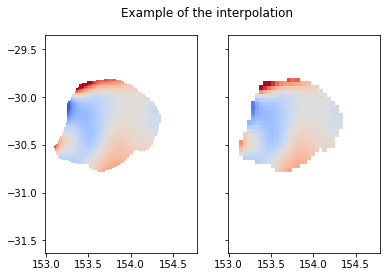

In [106]:
fig,axs=plt.subplots(ncols=2,sharex=True,sharey=True)
fig.suptitle('Example of the interpolation')
axs[0].pcolor(coffs['lon'],coffs['lat'],coffs['u'][500],vmin=-.5,vmax=.5,cmap='coolwarm')
axs[1].pcolor(coarse_coffs['lon'],coarse_coffs['lat'],coarse_coffs['u'][500],vmin=-.5,vmax=.5,cmap='coolwarm')

In [96]:
step = 3

#----- Coarsen Coffs
coarse_coffs = coffs.interp(x = coffs['x'][::step], 
                            y = coffs['y'][::step],
                            method='nearest')

u_coffs_coarse = coarse_coffs['u'].values
v_coffs_coarse = coarse_coffs['v'].values

lon_coffs_coarse = coarse_coffs['lon'].values
lat_coffs_coarse = coarse_coffs['lat'].values


coarse_newc = newc.interp(x = newc['x'][::1], 
                            y = newc['y'][::1],
                            method='nearest')

newcastle_u_coarse = coarse_newc['u'].values
newcastle_v_coarse = coarse_newc['v'].values

#----- Put on same timespan
u_newc_short = newcastle_u_coarse[:coarse_coffs['time'].shape[0],:,:]
v_newc_short = newcastle_v_coarse[:coarse_coffs['time'].shape[0],:,:]


#----- Mask both timesteps
condi_newc = ~np.isnan(np.nanmean(newc['u'],axis=(1,2)))
condi_newc_short = condi_newc[:coarse_coffs['time'].shape[0]]

condi_coffs = ~np.isnan(np.nanmean(coffs['u'],axis=(1,2)))

condi_both = np.logical_and(condi_coffs, condi_newc_short)

u1 = u_coffs_coarse[condi_both]
v1 = v_coffs_coarse[condi_both]

u2 = u_newc_short[condi_both]
v2 = v_newc_short[condi_both]

In [98]:
run_both_radars(u2, v2, u1, v1, rows=3, cols=3, name='coffs_newc')

You have chosen SOM spatial analysis
Your data shape is (489, 13778)
initializing
training
 [ 97800 / 97800 ] 100% - 0:00:00 elapsed  - 0:00:00 left 
 quantization error: 27.150402069091797
Duration: 0:00:04.215542
coffs_newc Done!
